# Hotel Review Satisfaction Classification: TF-IDF vs DistilBERT

**Research Question:** To what extent can automated text classification accurately infer hotel guest satisfaction ratings from review text, and does fine-tuned DistilBERT provide a practically meaningful improvement over a tuned TF-IDF Logistic Regression baseline for this five-class prediction task?

**Dataset:** [TripAdvisor Hotel Reviews](https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews) — Kaggle
**Task:** 5-class text classification (star ratings 1–5)
**Models compared:**
- **Model 1:** TF-IDF + Logistic Regression → tuned via `GridSearchCV`
- **Model 2:** DistilBERT fine-tuned → tuned via bounded learning rate search

---
**Before you run this notebook:**
1. Enable GPU: `Runtime → Change runtime type → T4 GPU`
2. Upload `tripadvisor_hotel_reviews.csv` to your Colab session (Files panel on the left)

---
## Section 0: Install Packages

We need a few libraries beyond what Colab pre-installs. `transformers` and `datasets` are from HuggingFace and handle everything related to DistilBERT. `accelerate` makes training faster on GPU.

In [1]:
!pip install -q -U transformers accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.4 MB/s eta 0:00:00


---
## Section 1: Imports and Configuration

We fix a **random seed = 42** at the start. This is important for reproducibility — running the notebook twice should give the same results.

Key libraries:
- `sklearn` — TF-IDF, Logistic Regression, GridSearchCV, metrics
- `transformers` — DistilBERT tokeniser, model, Trainer
- `datasets` — HuggingFace Dataset format (required by Trainer)
- `torch` — PyTorch backend for DistilBERT

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# HuggingFace
import torch
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          Trainer, TrainingArguments,
                          EarlyStoppingCallback)
from datasets import Dataset

warnings.filterwarnings('ignore')

# ── Fix all random seeds for reproducibility ─────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# ── Global settings ───────────────────────────────────────────────────────────
DATA_PATH    = 'tripadvisor_hotel_reviews.csv'  # update path if needed
OUTPUT_DIR   = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEST_SIZE       = 0.20
VAL_SIZE_BERT   = 0.10
NUM_CLASSES     = 5
MAX_SEQ_LEN     = 128
DISTILBERT_NAME = 'distilbert-base-uncased'
COMPLEXITY_THRESHOLD = 0.02   # min macro F1 gain to justify DistilBERT

print(f"CUDA available: {torch.cuda.is_available()}")
print("Seed:", SEED)

CUDA available: True
Seed: 42


---
## Section 2: Load the Data

The dataset is the **TripAdvisor Hotel Reviews** corpus. Each row contains:
- `Review` — the free-text hotel review written by a guest
- `Rating` — a star rating from 1 (worst) to 5 (best)

Our goal is to predict `Rating` from `Review` text alone.

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (20491, 2)
Columns: ['Review', 'Rating']


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3


In [4]:
# Rename to standard internal names
df = df.rename(columns={'Review': 'text', 'Rating': 'label'})

# Validate labels are 1–5
assert df['label'].between(1, 5).all(), "Unexpected label values!"

# Remove rows with missing or empty text
n_before = len(df)
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0]

print(f"Rows after cleaning: {len(df):,}  (dropped {n_before - len(df)})")

Rows after cleaning: 20,491  (dropped 0)


---
## Section 3: Exploratory Data Analysis (EDA)

Before modelling, we need to understand the data. Three things matter most here:

1. **Class distribution** — are ratings evenly spread, or skewed?
2. **Review length** — how long are reviews? Does length differ by rating?
3. **Sample reviews** — do the texts look reasonable?

This step directly informs our choice of evaluation metric.

=== Class Distribution ===
  1-star  ███                         6.9%  (1,421)
  2-star  ████                        8.8%  (1,793)
  3-star  █████                      10.7%  (2,184)
  4-star  ██████████████             29.5%  (6,039)
  5-star  ██████████████████████     44.2%  (9,054)


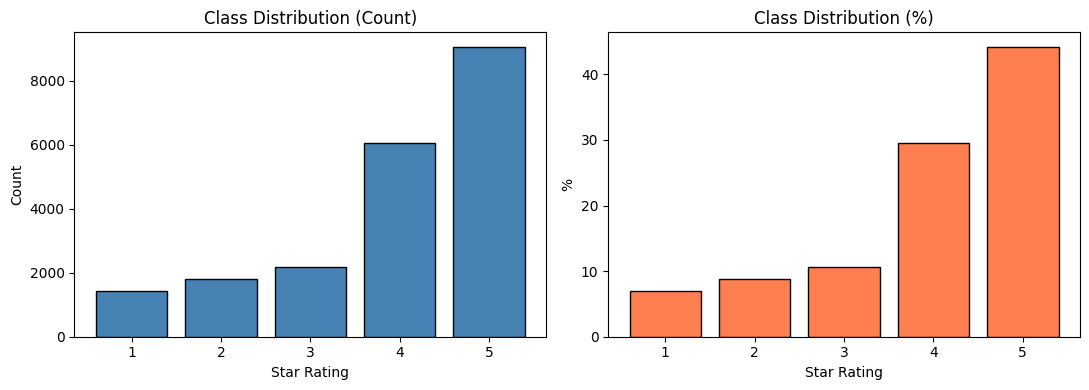

In [5]:
# ── Class distribution ───────────────────────────────────────────────────────
class_counts = df['label'].value_counts().sort_index()
class_pct    = (class_counts / len(df) * 100).round(1)

print("=== Class Distribution ===")
for r in range(1, 6):
    bar = '█' * int(class_pct[r] / 2)
    print(f"  {r}-star  {bar:<25} {class_pct[r]:5.1f}%  ({class_counts[r]:,})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
axes[0].set(title='Class Distribution (Count)', xlabel='Star Rating', ylabel='Count')
axes[1].bar(class_pct.index, class_pct.values, color='coral', edgecolor='black')
axes[1].set(title='Class Distribution (%)', xlabel='Star Rating', ylabel='%')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_class_distribution.png', dpi=150)
plt.show()

**What do we see?**

The distribution is heavily skewed towards 4- and 5-star reviews. This is ecologically realistic — satisfied guests are more likely to leave reviews — but it has an important implication:

> **Accuracy alone will be misleading.** A model that predicts "5-star" for every review would score high on accuracy but be useless. We must use **Macro F1** as our primary metric, which penalises failure on minority classes equally.

=== Review Length (words) ===
count    20491.0
mean       104.4
std        100.7
min          7.0
25%         48.0
50%         77.0
75%        124.0
max       1931.0
Name: word_count, dtype: float64
Mean word count by rating:
label
1    112.4
2    126.6
3    114.7
4    107.8
5     94.0
Name: word_count, dtype: float64


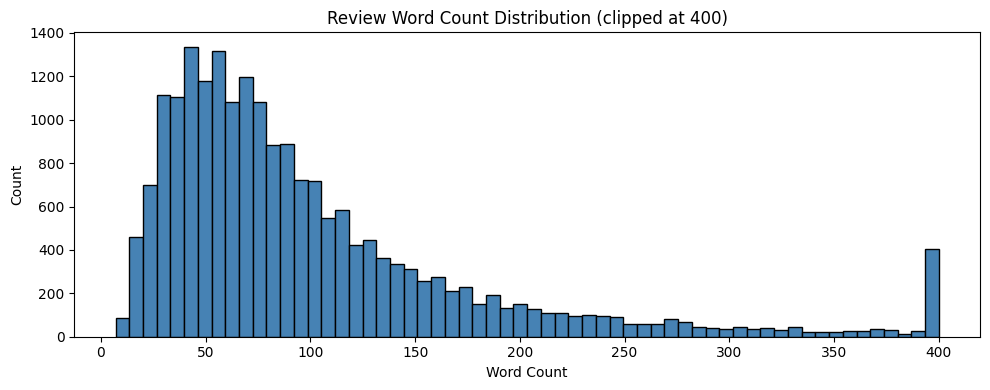

In [6]:
# ── Review length ────────────────────────────────────────────────────────────
df["word_count"] = df["text"].str.split().str.len()

print("=== Review Length (words) ===")
print(df["word_count"].describe().round(1))
print("Mean word count by rating:")
print(df.groupby("label")["word_count"].mean().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["word_count"].clip(upper=400), bins=60, color="steelblue", edgecolor="black")
ax.set(title="Review Word Count Distribution (clipped at 400)", xlabel="Word Count", ylabel="Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_length_distribution.png", dpi=150)
plt.show()

In [7]:
# ── Sample reviews (one per extreme rating) ──────────────────────────────────
for rating in [1, 3, 5]:
    sample = df[df['label'] == rating]['text'].iloc[0]
    print(f"[{rating}-star]: {sample[:300]}\n{'─'*60}")

[1-star]: horrible customer service hotel stay february 3rd 4th 2007my friend picked hotel monaco appealing website online package included champagne late checkout 3 free valet gift spa weekend, friend checked room hours earlier came later, pulled valet young man just stood, asked valet open said, pull bags d
────────────────────────────────────────────────────────────
[3-star]: nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wakeup calls, concierge busy hard touch, did n't provide
────────────────────────────────────────────────────────────
[5-star]: unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy

---
## Section 4: Train / Test Split

We split the data **before** any preprocessing. This is critical for avoiding **data leakage** — if the TF-IDF vocabulary is built on the full dataset (including test), the model has effectively "seen" the test data before evaluation.

**Design choices:**
- **80/20 split** — standard split; 20% is sufficient for reliable evaluation
- **`stratify=y`** — preserves the original class distribution in both splits; essential given our class imbalance
- **`random_state=42`** — reproducibility

We also shift labels from **1–5 → 0–4** because the DistilBERT classification head expects zero-indexed labels.

In [8]:
# Shift labels: 1–5 → 0–4  (required by HuggingFace classification head)
df['label_idx'] = df['label'] - 1

X = df['text'].values
y = df['label_idx'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y          # ← preserves class ratios
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print("\nClass proportions (train vs test — should match):")

TARGET_NAMES = [f'{i+1}-star' for i in range(NUM_CLASSES)]

for c in range(NUM_CLASSES):
    tr = (y_train == c).mean() * 100
    te = (y_test  == c).mean() * 100
    print(f"  {TARGET_NAMES[c]}:  train={tr:.1f}%  test={te:.1f}%")

Train: 16,392  |  Test: 4,099

Class proportions (train vs test — should match):
  1-star:  train=6.9%  test=6.9%
  2-star:  train=8.7%  test=8.8%
  3-star:  train=10.7%  test=10.7%
  4-star:  train=29.5%  test=29.5%
  5-star:  train=44.2%  test=44.2%


---
## Section 5: Model 1 — TF-IDF + Logistic Regression

### What is TF-IDF + Logistic Regression?

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts each review into a vector of numbers. Each number represents how important a word is to that review, relative to all reviews.

- **TF (Term Frequency):** how often a word appears in *this* review
- **IDF (Inverse Document Frequency):** how rare the word is across *all* reviews — common words like "the" get down-weighted

**Logistic Regression** then finds a linear decision boundary in this high-dimensional word-space to separate the 5 classes.

### Why use a Pipeline?

All TF-IDF steps are wrapped in a `Pipeline` with the classifier. This ensures the vocabulary is **fitted only on training data** — if we built the vocabulary on the full dataset first, the model would have illegitimately "seen" words from the test set.

### Why GridSearchCV?

Model rankings from default settings can be **unstable**. We use `GridSearchCV` to systematically try 72 combinations of parameters and pick the best one, judged by **macro F1** on 5-fold cross-validation.

In [9]:
# ── Define the pipeline (all transforms inside → no leakage) ─────────────────
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(max_iter=1000, random_state=SEED))
])

# ── Search space ──────────────────────────────────────────────────────────────
# max_features : how large the vocabulary is
# ngram_range  : (1,2) adds bigrams — "not good", "very clean"
# sublinear_tf : log-scale TF to reduce impact of very frequent words
# C            : regularisation strength (lower = more regularisation)
# class_weight : 'balanced' up-weights minority classes during training
param_grid = {
    'tfidf__max_features' : [10_000, 30_000, 50_000],
    'tfidf__ngram_range'  : [(1, 1), (1, 2)],
    'tfidf__sublinear_tf' : [True, False],
    'clf__C'              : [0.1, 1.0, 10.0],
    'clf__class_weight'   : [None, 'balanced'],
}

# ── GridSearchCV with 5-fold stratified cross-validation ──────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator  = lr_pipeline,
    param_grid = param_grid,
    cv         = skf,
    scoring    = 'f1_macro',   # optimise for our primary metric
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

print("Running GridSearchCV (72 combinations × 5 folds = 360 fits)...")
print("This takes ~10–15 minutes on Colab CPU...\n")
grid_search.fit(X_train, y_train)

print(f"\nBest CV Macro F1 : {grid_search.best_score_:.4f}")
print(f"Best parameters  : {grid_search.best_params_}")

Running GridSearchCV (72 combinations × 5 folds = 360 fits)...
This takes ~10–15 minutes on Colab CPU...

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best CV Macro F1 : 0.5590
Best parameters  : {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


In [10]:
# ── Evaluate on held-out test set ─────────────────────────────────────────────
best_lr = grid_search.best_estimator_
y_pred_lr = best_lr.predict(X_test)

acc_lr         = accuracy_score(y_test, y_pred_lr)
macro_f1_lr    = f1_score(y_test, y_pred_lr, average='macro')
weighted_f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
per_class_f1_lr = f1_score(y_test, y_pred_lr, average=None)

print("=== TF-IDF + LR (tuned) — Test Set ===")
print(f"  Accuracy     : {acc_lr:.4f}")
print(f"  Macro F1     : {macro_f1_lr:.4f}   ← primary metric")
print(f"  Weighted F1  : {weighted_f1_lr:.4f}")
print("\nFull report:")
print(classification_report(y_test, y_pred_lr, target_names=TARGET_NAMES))

=== TF-IDF + LR (tuned) — Test Set ===
  Accuracy     : 0.6141
  Macro F1     : 0.5542   ← primary metric
  Weighted F1  : 0.6161

Full report:
              precision    recall  f1-score   support

      1-star       0.63      0.73      0.68       284
      2-star       0.41      0.45      0.43       359
      3-star       0.37      0.38      0.37       437
      4-star       0.54      0.54      0.54      1208
      5-star       0.77      0.74      0.75      1811

    accuracy                           0.61      4099
   macro avg       0.55      0.57      0.55      4099
weighted avg       0.62      0.61      0.62      4099



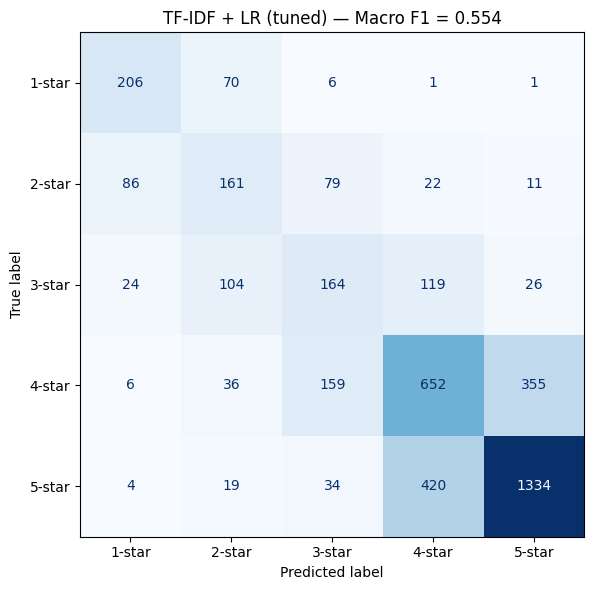

In [11]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=TARGET_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'TF-IDF + LR (tuned) — Macro F1 = {macro_f1_lr:.3f}')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_cm_lr.png', dpi=150)
plt.show()

**What to look for in the confusion matrix:**

The rows are the **actual** labels; the columns are the **predicted** labels. Large numbers on the diagonal = correct predictions.

Look for off-diagonal concentrations — especially between adjacent classes (e.g., 4-star predicted as 5-star). This is called **adjacent-class confusion** and is expected because the linguistic difference between "very good" and "excellent" is subtle.

---
## Section 6: Model 2 — DistilBERT Fine-Tuning

### Why DistilBERT?

TF-IDF represents text as a **bag of words** — it loses word order and context. DistilBERT uses **contextual embeddings** from a transformer architecture:

| | TF-IDF | DistilBERT |
|---|---|---|
| Represents | Individual word frequencies | Full sentence context |
| Handles "not good" | Partially (bigrams) | Yes — understands negation |
| Pre-trained? | No | Yes — on 8GB of text |
| Training time | ~10 min | ~30 min (GPU) |
| Interpretable? | Yes (feature weights) | No (66M parameters) |

**DistilBERT** is a compressed version of BERT — it retains ~97% of BERT's performance at 40% fewer parameters, making it practical for Colab.

### What is fine-tuning?

DistilBERT was pre-trained on Wikipedia and BooksCorpus to understand English in general. **Fine-tuning** means we continue training on *our* hotel review data, adjusting its weights to specialise in star rating prediction.

### Hyperparameter choices

For DistilBERT, a full grid search is not feasible on free Colab GPU. Instead we use a **bounded principled search**:
- We try **two learning rates** (2e-5 and 3e-5) — both within the range recommended by Devlin et al. (2019)
- All other settings are justified a priori (see comments in code)
- We select the better learning rate using a **validation split** — *not* the test set

In [12]:
# ── Check we have GPU ─────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cpu':
    print("⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU")

Device: cuda


In [13]:
# ── Create a validation split from training data ──────────────────────────────
# This is used ONLY to select the best learning rate.
# The test set (X_test) is NOT touched until Section 7.
X_tr_bert, X_val_bert, y_tr_bert, y_val_bert = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE_BERT,
    random_state=SEED,
    stratify=y_train
)
print(f"BERT train: {len(X_tr_bert):,}  |  val: {len(X_val_bert):,}")

BERT train: 14,752  |  val: 1,640


In [14]:
# ── Load the DistilBERT tokeniser ─────────────────────────────────────────────
# The tokeniser converts raw text into token IDs that the model understands.
# Tokenisation happens AFTER splitting — no leakage.
print(f"Loading tokeniser: {DISTILBERT_NAME}")
tokenizer = DistilBertTokenizerFast.from_pretrained(DISTILBERT_NAME)

def make_hf_dataset(texts, labels):
    """Tokenise texts and wrap in a HuggingFace Dataset for the Trainer."""
    enc = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=MAX_SEQ_LEN   # reviews > 128 tokens are truncated
    )
    ds = Dataset.from_dict({
        'input_ids'      : enc['input_ids'],
        'attention_mask' : enc['attention_mask'],
        'labels'         : list(labels)
    })
    ds.set_format('torch')
    return ds

print("Tokenising splits...")
hf_train = make_hf_dataset(X_tr_bert,  y_tr_bert)
hf_val   = make_hf_dataset(X_val_bert, y_val_bert)
hf_test  = make_hf_dataset(X_test,     y_test)
print("Done.")

Loading tokeniser: distilbert-base-uncased


Tokenising splits...
Done.


In [15]:
# ── Metric function for HuggingFace Trainer ──────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'macro_f1' : f1_score(labels, preds, average='macro')
    }

### Training with Two Learning Rates

We train DistilBERT twice — once with `lr=2e-5` and once with `lr=3e-5` — then compare validation macro F1 to select the better one.

**Why these two values?**
- `2e-5` — conservative; reduces the risk of **catastrophic forgetting** (overwriting the pre-trained knowledge)
- `3e-5` — slightly more aggressive; sometimes gives faster convergence

Both are within the range recommended by the original BERT paper (Devlin et al., 2019).

In [16]:
lr_val_results = {}

for lr in [2e-5, 3e-5]:
    print(f"\n{'='*50}")
    print(f"Training DistilBERT  lr = {lr}")
    print('='*50)
    set_seed(SEED)

    model = DistilBertForSequenceClassification.from_pretrained(
        DISTILBERT_NAME, num_labels=NUM_CLASSES)

    args = TrainingArguments(
        output_dir                  = f'{OUTPUT_DIR}/bert_lr{lr}',
        num_train_epochs            = 3,          # 3 epochs: standard for fine-tuning
        per_device_train_batch_size = 16,         # safe for Colab T4 GPU
        per_device_eval_batch_size  = 32,
        learning_rate               = lr,
        weight_decay                = 0.01,       # L2 regularisation via AdamW
        warmup_steps                = 100,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'macro_f1',
        greater_is_better           = True,
        logging_steps               = 100,
        seed                        = SEED,
        fp16                        = torch.cuda.is_available(),  # mixed precision on GPU
        report_to                   = 'none'
    )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = hf_train,
        eval_dataset    = hf_val,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    val_metrics = {'eval_macro_f1': trainer.state.best_metric}

    lr_val_results[lr] = {
        'val_macro_f1' : val_metrics['eval_macro_f1'],
        'trainer'      : trainer
    }
    print(f"  Val Macro F1: {val_metrics['eval_macro_f1']:.4f}")


Training DistilBERT  lr = 2e-05


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.789430,0.813457,0.657927,0.549620
2,0.705663,0.731923,0.678659,0.618643
3,0.573183,0.757799,0.685976,0.624654


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  Val Macro F1: 0.6247

Training DistilBERT  lr = 3e-05


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.785610,0.807612,0.652439,0.549436
2,0.680169,0.742075,0.671951,0.622667
3,0.526338,0.786910,0.679878,0.615885


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  Val Macro F1: 0.6227


In [17]:
# ── Select best learning rate ─────────────────────────────────────────────────
best_lr_bert = max(lr_val_results, key=lambda lr: lr_val_results[lr]['val_macro_f1'])
print(f"\nSelected learning rate: {best_lr_bert}")
print(f"Validation Macro F1   : {lr_val_results[best_lr_bert]['val_macro_f1']:.4f}")

best_trainer = lr_val_results[best_lr_bert]['trainer']


Selected learning rate: 2e-05
Validation Macro F1   : 0.6247


In [18]:
# ── Evaluate on held-out test set ─────────────────────────────────────────────
print("=== DistilBERT (tuned) — Test Set ===")
test_preds  = best_trainer.predict(hf_test)
y_pred_bert = np.argmax(test_preds.predictions, axis=-1)

acc_bert          = accuracy_score(y_test, y_pred_bert)
macro_f1_bert     = f1_score(y_test, y_pred_bert, average='macro')
weighted_f1_bert  = f1_score(y_test, y_pred_bert, average='weighted')
per_class_f1_bert = f1_score(y_test, y_pred_bert, average=None)

print(f"  Accuracy     : {acc_bert:.4f}")
print(f"  Macro F1     : {macro_f1_bert:.4f}   ← primary metric")
print(f"  Weighted F1  : {weighted_f1_bert:.4f}")
print("\nFull report:")
print(classification_report(y_test, y_pred_bert, target_names=TARGET_NAMES))

=== DistilBERT (tuned) — Test Set ===


  Accuracy     : 0.6663
  Macro F1     : 0.6021   ← primary metric
  Weighted F1  : 0.6629

Full report:
              precision    recall  f1-score   support

      1-star       0.69      0.73      0.71       284
      2-star       0.49      0.47      0.48       359
      3-star       0.48      0.41      0.44       437
      4-star       0.58      0.59      0.58      1208
      5-star       0.78      0.81      0.80      1811

    accuracy                           0.67      4099
   macro avg       0.61      0.60      0.60      4099
weighted avg       0.66      0.67      0.66      4099



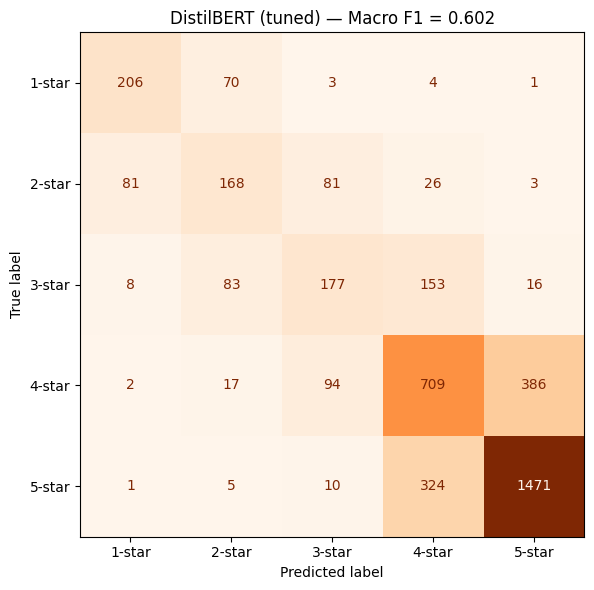

In [19]:
cm_bert = confusion_matrix(y_test, y_pred_bert)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=TARGET_NAMES).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'DistilBERT (tuned) — Macro F1 = {macro_f1_bert:.3f}')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_cm_bert.png', dpi=150)
plt.show()

---
## Section 7: Model Comparison and Final Selection

Now we compare both tuned models side-by-side and make a **principled final selection**.

A key principle: we don't automatically assume DistilBERT is better just because it's more complex. We define a **complexity threshold of 2 macro F1 points** — if DistilBERT's gain is smaller than this, the simpler and more interpretable TF-IDF+LR is preferred.

In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model'       : ['TF-IDF + LR (tuned)', f'DistilBERT lr={best_lr_bert} (tuned)'],
    'Accuracy'    : [acc_lr,         acc_bert],
    'Macro F1'    : [macro_f1_lr,    macro_f1_bert],
    'Weighted F1' : [weighted_f1_lr, weighted_f1_bert],
}).set_index('Model')

print("Table 1: Test-Set Performance (after hyperparameter tuning)")
print(results_df.round(4))
results_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv')

Table 1: Test-Set Performance (after hyperparameter tuning)
                             Accuracy  Macro F1  Weighted F1
Model                                                       
TF-IDF + LR (tuned)            0.6141    0.5542       0.6161
DistilBERT lr=2e-05 (tuned)    0.6663    0.6021       0.6629


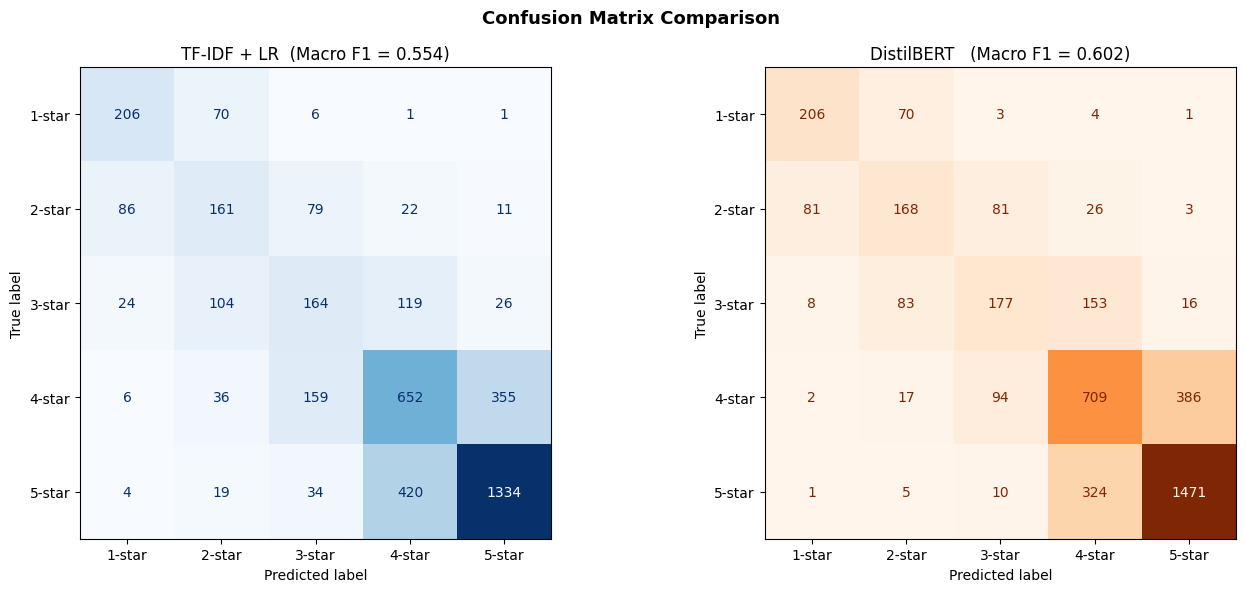

In [21]:
# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=TARGET_NAMES).plot(ax=axes[0], cmap='Blues',   colorbar=False)
ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=TARGET_NAMES).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[0].set_title(f'TF-IDF + LR  (Macro F1 = {macro_f1_lr:.3f})')
axes[1].set_title(f'DistilBERT   (Macro F1 = {macro_f1_bert:.3f})')
plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_cm_comparison.png', dpi=150)
plt.show()

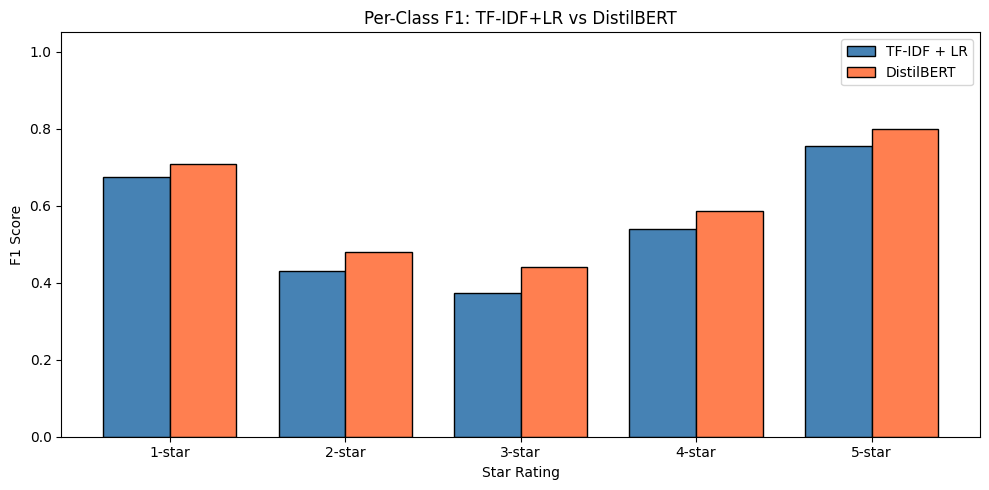

In [22]:
# ── Per-class F1 comparison ───────────────────────────────────────────────────
x = np.arange(NUM_CLASSES)
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, per_class_f1_lr,   w, label='TF-IDF + LR', color='steelblue', edgecolor='black')
ax.bar(x + w/2, per_class_f1_bert, w, label='DistilBERT',  color='coral',     edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(TARGET_NAMES)
ax.set(xlabel='Star Rating', ylabel='F1 Score', ylim=(0, 1.05),
       title='Per-Class F1: TF-IDF+LR vs DistilBERT')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_per_class_f1.png', dpi=150)
plt.show()

**Interpreting the per-class chart:**

- Which classes does each model handle well? Where do they fail?
- If DistilBERT improves mainly on middle classes (2-, 3-star), this is consistent with its advantage in encoding contextual nuance
- If performance is similar on all classes, the simpler model may be sufficient

In [23]:
# ── Final model selection ─────────────────────────────────────────────────────
f1_gain = macro_f1_bert - macro_f1_lr
print(f"Macro F1 gain (DistilBERT − LR) : {f1_gain:+.4f}")
print(f"Complexity threshold             : {COMPLEXITY_THRESHOLD}")

if f1_gain >= COMPLEXITY_THRESHOLD:
    final_model   = "DistilBERT"
    justification = (f"DistilBERT achieves a {f1_gain:.4f} macro F1 improvement "
                     f"({macro_f1_bert:.4f} vs {macro_f1_lr:.4f}). This exceeds "
                     f"the complexity threshold of {COMPLEXITY_THRESHOLD}, "
                     f"justifying the additional computational cost.")
else:
    final_model   = "TF-IDF + Logistic Regression"
    justification = (f"DistilBERT's gain ({f1_gain:+.4f}) does not exceed "
                     f"the complexity threshold of {COMPLEXITY_THRESHOLD}. "
                     f"TF-IDF+LR is preferred for its interpretability and "
                     f"deployment simplicity.")

print(f"\n{'='*55}")
print(f"FINAL MODEL : {final_model}")
print(f"REASON      : {justification}")
print('='*55)

with open(f'{OUTPUT_DIR}/final_model_selection.txt', 'w') as f:
    f.write(f"FINAL MODEL: {final_model}\n\nJUSTIFICATION:\n{justification}\n\n")
    f.write(results_df.round(4).to_string())

Macro F1 gain (DistilBERT − LR) : +0.0479
Complexity threshold             : 0.02

FINAL MODEL : DistilBERT
REASON      : DistilBERT achieves a 0.0479 macro F1 improvement (0.6021 vs 0.5542). This exceeds the complexity threshold of 0.02, justifying the additional computational cost.


In [24]:
# ── Error analysis: misclassified examples ────────────────────────────────────
import pandas as pd

errors_df = pd.DataFrame({
    'text'      : X_test,
    'true'      : y_test + 1,          # shift back to 1–5
    'pred_lr'   : y_pred_lr + 1,
    'pred_bert' : y_pred_bert + 1,
})

# Adjacent-class errors only (predicted ±1 from true)
adjacent = errors_df[
    (abs(errors_df['true'] - errors_df['pred_bert']) == 1)
].copy()

# Exact errors (both models wrong in same direction)
both_wrong = errors_df[
    (errors_df['pred_lr'] != errors_df['true']) &
    (errors_df['pred_bert'] != errors_df['true'])
].copy()

print(f"Total test samples     : {len(errors_df):,}")
print(f"Adjacent-class errors  : {len(adjacent):,}  ({len(adjacent)/len(errors_df)*100:.1f}%)")
print(f"Both models wrong      : {len(both_wrong):,}  ({len(both_wrong)/len(errors_df)*100:.1f}%)\n")

# Show 3 interesting examples: true=2 or 3, predicted differently by each model
interesting = errors_df[
    (errors_df['true'].isin([2, 3])) &
    (errors_df['pred_lr'] != errors_df['true']) &
    (errors_df['pred_bert'] != errors_df['true'])
].head(5)

print("=== Sample misclassified reviews (mid-tier) ===")
for _, row in interesting.iterrows():
    print(f"\n[TRUE: {row['true']}-star | LR predicted: {row['pred_lr']} | BERT predicted: {row['pred_bert']}]")
    print(row['text'][:300])
    print("─" * 60)

Total test samples     : 4,099
Adjacent-class errors  : 1,272  (31.0%)
Both models wrong      : 950  (23.2%)

=== Sample misclassified reviews (mid-tier) ===

[TRUE: 3-star | LR predicted: 4 | BERT predicted: 4]
nice hotel nice hotel good area explore, arrival greated glass bubbly juice, arrived early room ready great, room road noisy night room quite hot sleep window open extremely noisy, bathroom okay water shower going not problem used towels reception bought towels quite quickly, rooms clean bed comfort
────────────────────────────────────────────────────────────

[TRUE: 2-star | LR predicted: 3 | BERT predicted: 3]
not bad not great night, room adequate size nicely furnished price 250 euros including buffet breakfast bed quite hard.the bathroom good, buffet breakfast mediocre poor coffee charged seperately 20 euro unhappy, staff excellent helpfull, location suburb, decent value location think better,
────────────────────────────────────────────────────────────

[TRUE: 2-star | LR 

---
## Section 8: Save Outputs

Download all results before your Colab session ends — files are lost when the session closes.

In [25]:
# List all saved files
print(f"Files saved to {OUTPUT_DIR}/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f"  {f:<45} {size:>6.1f} KB")

Files saved to ./outputs/:
  bert_lr2e-05                                     4.0 KB
  bert_lr3e-05                                     4.0 KB
  fig1_class_distribution.png                     31.1 KB
  fig2_length_distribution.png                    35.9 KB
  fig3_cm_lr.png                                  47.3 KB
  fig4_cm_bert.png                                46.4 KB
  fig5_cm_comparison.png                          82.9 KB
  fig6_per_class_f1.png                           30.7 KB
  final_model_selection.txt                        0.4 KB
  model_comparison.csv                             0.2 KB


In [26]:
# ── Download everything as a zip ──────────────────────────────────────────────
import shutil
from google.colab import files

shutil.make_archive('outputs', 'zip', './outputs')
files.download('outputs.zip')
print("Download started — save outputs.zip to your computer.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — save outputs.zip to your computer.


---
## Wrap-Up

### What You Accomplished
- ✅ Loaded and explored the TripAdvisor hotel review dataset
- ✅ Identified class imbalance and justified Macro F1 as the primary metric
- ✅ Trained and tuned TF-IDF + Logistic Regression using GridSearchCV (72 combinations)
- ✅ Fine-tuned DistilBERT with a principled bounded learning rate search
- ✅ Compared both models on a held-out test set and selected a final model

### Reproducibility note
Random seed `42` is fixed throughout. Re-running this notebook from top to bottom should give identical results.